In [18]:
import joblib
import pandas as pd
import tensorflow as tf
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

### TensorFlow Version of 'human-activity-recognition' (previously: sklearn)

In [ ]:
feature_df = joblib.load("../models/features_kognihome_50.pkl")

X = feature_df.drop(columns=["activity"])
y = feature_df["activity"]


encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

joblib.dump(encoder, "../models/label_encoder.pkl")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42,
)

X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

# low f1-score compared to tree-based model; fix for feature scale problem?
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

num_features = X_train.shape[1]
num_classes = len(encoder.classes_)

# Neural network
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(num_features,)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# class-imbalance; fix?
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(weights))

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    class_weight=class_weights
)

y_pred = model.predict(X_test)
y_pred = y_pred.argmax(axis=1)

print(classification_report(y_test, y_pred, zero_division=0))

Epoch 1/50


258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0069 - loss: nan - val_accuracy: 0.0097 - val_loss: nan
Epoch 2/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0069 - loss: nan - val_accuracy: 0.0097 - val_loss: nan
Epoch 3/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0069 - loss: nan - val_accuracy: 0.0097 - val_loss: nan
Epoch 4/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0069 - loss: nan - val_accuracy: 0.0097 - val_loss: nan
Epoch 5/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0069 - loss: nan - val_accuracy: 0.0097 - val_loss: nan
Epoch 6/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0069 - loss: nan - val_accuracy: 0.0097 - val_loss: nan
Epoch 7/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0069 - loss: nan - val_accuracy: 0.0097 - val_loss: nan
Epoch 8/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0069 - loss: nan - val_accuracy: 0.0097 - val_loss: nan
Epoch 9/50
258/258 ━━━━━━━━━━━━━━━━

/usr/local/python/3.13.14/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/python/3.13.14/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/python/3.13.14/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

### Network learning history

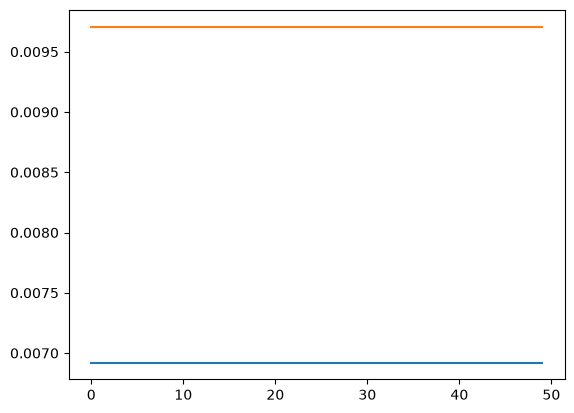

In [20]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.show()

### Convert to TFLite after Training is complete

In [21]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

tflite_model = converter.convert()

with open("../models/kognihome.tflite", "wb") as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: /tmp/tmpe9rnnqk0/assets


INFO:tensorflow:Assets written to: /tmp/tmpe9rnnqk0/assets


Saved artifact at '/tmp/tmpe9rnnqk0'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 30), dtype=tf.float32, name='keras_tensor_16')
Output Type:
  TensorSpec(shape=(None, 14), dtype=tf.float32, name=None)
Captures:
  139929905523472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139929905516752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139929905516560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139929905517136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139929905516944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139929905520976: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1781546733.214407    1582 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1781546733.214442    1582 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1781546733.214602    1582 reader.cc:83] Reading SavedModel from: /tmp/tmpe9rnnqk0
I0000 00:00:1781546733.214828    1582 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1781546733.214832    1582 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpe9rnnqk0
I0000 00:00:1781546733.217043    1582 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1781546733.231516    1582 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpe9rnnqk0
I0000 00:00:1781546733.236025    1582 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 21432 microseconds.


### Quantized Version for the STM32N6

In [22]:
def representative_dataset():
    for i in range(min(1000, len(X_train))):
        yield [X_train.iloc[i:i+1].values.astype("float32")]


converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_quant = converter.convert()

with open("../models/kognihome_int8.tflite", "wb") as f:
    f.write(tflite_quant)

INFO:tensorflow:Assets written to: /tmp/tmp8vblauf0/assets


INFO:tensorflow:Assets written to: /tmp/tmp8vblauf0/assets


Saved artifact at '/tmp/tmp8vblauf0'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 30), dtype=tf.float32, name='keras_tensor_16')
Output Type:
  TensorSpec(shape=(None, 14), dtype=tf.float32, name=None)
Captures:
  139929905523472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139929905516752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139929905516560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139929905517136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139929905516944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139929905520976: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/python/3.13.14/lib/python3.13/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1781546733.502265    1582 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1781546733.502297    1582 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1781546733.502408    1582 reader.cc:83] Reading SavedModel from: /tmp/tmp8vblauf0
I0000 00:00:1781546733.502631    1582 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1781546733.502635    1582 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp8vblauf0
I0000 00:00:1781546733.504767    1582 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1781546733.518073    1582 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp8vblauf0
I0000 00:00:1781546733.522686    1582 loader.cc:471] SavedModel load for tags {

AttributeError: 'numpy.ndarray' object has no attribute 'iloc'

### Verify TFLite Model

In [ ]:
interpreter = tf.lite.Interpreter("../models/kognihome_int8.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(input_details)
print(output_details)

[{'name': 'serving_default_keras_tensor:0', 'index': 0, 'shape': array([ 1, 30], dtype=int32), 'shape_signature': array([-1, 30], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (16.68600082397461, -128), 'quantization_parameters': {'scales': array([16.686], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}]
[{'name': 'StatefulPartitionedCall_1:0', 'index': 12, 'shape': array([ 1, 14], dtype=int32), 'shape_signature': array([-1, 14], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.00390625, -128), 'quantization_parameters': {'scales': array([0.00390625], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}]
